In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

sns.set_theme(style="whitegrid")
BASE_URL = "https://api.worldbank.org/v2"
TIMEOUT = 60

session = requests.Session()
retry = Retry(
    total=5,
    connect=5,
    read=5,
    backoff_factor=1,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))
session.mount("http://", HTTPAdapter(max_retries=retry))

Explorar el API

In [2]:
url = f"{BASE_URL}/country"
params = {
    "format": "json",
    "per_page": 50,
    "page": 1,
}

response = session.get(url, params=params, timeout=TIMEOUT)
response.raise_for_status()
payload = response.json()

print("Pagination metadata:", payload[0])
print("First country record:", payload[1][0])

Pagination metadata: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
First country record: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


DESCARGAR LOS DATOS

In [3]:
countries = ["ARG", "BRA", "CHL", "COL", "MEX"]
indicators = {
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SP.DYN.LE00.IN": "life_expectancy",
    "EN.ATM.CO2E.PC": "co2_per_capita",
}

def fetch_indicator_data(country_codes, indicator_id, start_year=2010, end_year=2024):
    country_path = ";".join(country_codes)
    endpoint = f"{BASE_URL}/country/{country_path}/indicator/{indicator_id}"
    page = 1
    all_rows = []

    while True:
        params = {
            "format": "json",
            "date": f"{start_year}:{end_year}",
            "per_page": 50,
            "page": page,
        }

        response = session.get(endpoint, params=params, timeout=TIMEOUT)
        response.raise_for_status()
        payload = response.json()

        if not isinstance(payload, list) or len(payload) == 0:
            raise ValueError(f"Unexpected API response for {indicator_id}: {payload}")

        metadata = payload[0]
        rows = payload[1] if len(payload) > 1 and payload[1] is not None else []
        all_rows.extend(rows)

        total_pages = int(metadata.get("pages", 1))
        if page >= total_pages:
            break
        page += 1

    return all_rows

TRANSFORMAR RESPUESTA A DATAFRAMES

In [4]:
tables = {}

for indicator_id, table_name in indicators.items():
    raw_rows = fetch_indicator_data(countries, indicator_id, 2010, 2024)

    records = []
    for row in raw_rows:
        records.append({
            "country": row["country"]["value"],
            "year": row["date"],
            "value": row["value"],
        })

    df = pd.DataFrame(records, columns=["country", "year", "value"])
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value", "year"]).copy()
    df["year"] = df["year"].astype(int)
    df = df.sort_values(["country", "year"]).reset_index(drop=True)

    tables[table_name] = df

tables["gdp_per_capita"].head()

,country,year,value
0,Argentina,2010,10260.131311
1,Argentina,2011,12704.283182
2,Argentina,2012,12949.717487
3,Argentina,2013,12963.675773
4,Argentina,2014,12233.144412


VISUALIZAR

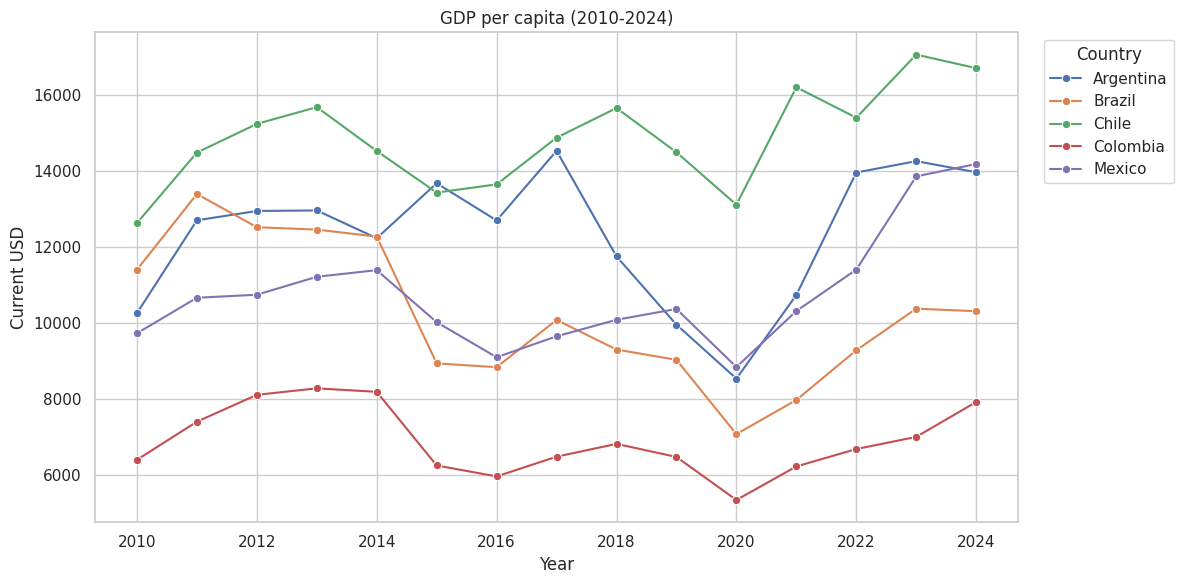

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=tables["gdp_per_capita"], x="year", y="value", hue="country", marker="o")
plt.title("GDP per capita (2010-2024)")
plt.xlabel("Year")
plt.ylabel("Current USD")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

GUARDAR A SQL

In [7]:
from sqlalchemy import create_engine

In [10]:
import sqlite3
conn = sqlite3.connect("world_bank_analysis.db")

for table_name, df in tables.items():
    df.to_sql(f"indicator_{table_name}", con=conn, if_exists="replace", index=False)